In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt
import seaborn as sns
from tensorflow.keras.initializers import he_normal
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Input, ZeroPadding1D
from tensorflow.keras.layers import MaxPooling1D, Add, AveragePooling1D
from tensorflow.keras.layers import Dense, BatchNormalization, Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Model
from keras.initializers import glorot_uniform
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.manifold import TSNE
import time
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense, InputLayer
from tensorflow.keras.initializers import glorot_uniform
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical
from collections import Counter
from keras.metrics import Recall, Precision
from imblearn.pipeline import Pipeline
import joblib
from tensorflow.keras.regularizers import l2
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:

label_col = "Attack_type"


In [3]:
df = pd.read_csv('./preprocessed_DNN.csv', low_memory=False)
feat_cols = list(df.columns)

feat_cols.remove(label_col)
feat_cols

skip_list = ["icmp.unused", "http.tls_port", "dns.qry.type", "mqtt.msg_decoded_as", "Attack_label"]

df.drop(skip_list, axis=1, inplace=True)
feat_cols = list(df.columns)
feat_cols.remove(label_col)

In [4]:
df

,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,http.content_length,http.response,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,...,mqtt.conack.flags-1471198,mqtt.conack.flags-1471199,mqtt.conack.flags-1574358,mqtt.conack.flags-1574359,mqtt.protoname-0,mqtt.protoname-0.0,mqtt.protoname-MQTT,mqtt.topic-0,mqtt.topic-0.0,mqtt.topic-Temperature_and_Humidity
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.647490e+09,1594.0,0.0,...,False,False,False,False,True,False,False,True,False,False
1,0.0,0.0,0.0,0.0,0.0,0.0,59.0,3.411509e+09,54649.0,1.0,...,False,False,False,False,True,False,False,True,False,False
2,0.0,0.0,0.0,0.0,0.0,0.0,5.0,1.099419e+09,31572.0,0.0,...,False,False,False,False,True,False,False,False,False,True
3,0.0,0.0,0.0,0.0,0.0,0.0,59.0,1.185254e+09,54569.0,0.0,...,False,False,False,False,True,False,False,True,False,False
4,0.0,0.0,0.0,0.0,0.0,0.0,56.0,1.795444e+09,36563.0,0.0,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1909666,0.0,0.0,0.0,0.0,0.0,0.0,115678289.0,1.254530e+09,30876.0,0.0,...,False,False,False,False,True,False,False,True,False,False
1909667,0.0,0.0,0.0,0.0,0.0,0.0,56.0,1.594269e+09,11256.0,0.0,...,False,False,False,False,True,False,False,True,False,False
1909668,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.213215e+09,59837.0,0.0,...,False,False,False,False,False,True,False,False,True,False
1909669,0.0,0.0,0.0,0.0,0.0,0.0,479.0,4.273690e+09,7664.0,0.0,...,False,False,False,False,False,True,False,False,True,False


In [5]:
df.Attack_type.value_counts()

Attack_type
Normal                   1363998
DDoS_UDP                  121567
DDoS_ICMP                  67939
SQL_injection              50826
DDoS_TCP                   50062
Vulnerability_scanner      50026
Password                   49933
DDoS_HTTP                  48544
Uploading                  36807
Backdoor                   24026
Port_Scanning              19977
XSS                        15066
Ransomware                  9689
Fingerprinting               853
MITM                         358
Name: count, dtype: int64

# Preprocessing (normalization and padding values)

In [6]:
# Z-score normalization
features = df.dtypes[df.dtypes != 'object'].index
df[features] = df[features].apply(
    lambda x: (x - x.mean()) / (x.std()))
# Fill empty values by 0
df = df.fillna(0)

In [7]:
label_encoder = LabelEncoder()
df['Attack_type'] = label_encoder.fit_transform(df['Attack_type'])


In [8]:
df.Attack_type.value_counts()

Attack_type
7     1363998
4      121567
2       67939
11      50826
3       50062
13      50026
8       49933
1       48544
12      36807
0       24026
9       19977
14      15066
10       9689
5         853
6         358
Name: count, dtype: int64

In [9]:
X_fs = df.drop([label_col], axis=1)
y = df[label_col]

#del df

In [10]:
X_fs

,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,http.content_length,http.response,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,...,mqtt.conack.flags-1471198,mqtt.conack.flags-1471199,mqtt.conack.flags-1574358,mqtt.conack.flags-1574359,mqtt.protoname-0,mqtt.protoname-0.0,mqtt.protoname-MQTT,mqtt.topic-0,mqtt.topic-0.0,mqtt.topic-Temperature_and_Humidity
0,-0.003437,-0.003618,-0.166331,-0.179964,-0.053767,-0.131792,-0.149153,-0.061580,-1.361015,-0.335034,...,-0.001023,-0.001023,-0.002171,-0.002171,0.700563,-0.632498,-0.213186,0.700561,-0.632498,-0.213182
1,-0.003437,-0.003618,-0.166331,-0.179964,-0.053767,-0.131792,-0.149152,1.297649,1.229695,2.984767,...,-0.001023,-0.001023,-0.002171,-0.002171,0.700563,-0.632498,-0.213186,0.700561,-0.632498,-0.213182
2,-0.003437,-0.003618,-0.166331,-0.179964,-0.053767,-0.131792,-0.149153,-0.483885,0.102830,-0.335034,...,-0.001023,-0.001023,-0.002171,-0.002171,0.700563,-0.632498,-0.213186,-1.427427,-0.632498,4.690833
3,-0.003437,-0.003618,-0.166331,-0.179964,-0.053767,-0.131792,-0.149152,-0.417746,1.225788,-0.335034,...,-0.001023,-0.001023,-0.002171,-0.002171,0.700563,-0.632498,-0.213186,0.700561,-0.632498,-0.213182
4,-0.003437,-0.003618,-0.166331,-0.179964,-0.053767,-0.131792,-0.149152,0.052423,0.346544,-0.335034,...,-0.001023,-0.001023,-0.002171,-0.002171,0.700563,-0.632498,-0.213186,0.700561,-0.632498,-0.213182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1909666,-0.003437,-0.003618,-0.166331,-0.179964,-0.053767,-0.131792,0.502600,-0.364367,0.068844,-0.335034,...,-0.001023,-0.001023,-0.002171,-0.002171,0.700563,-0.632498,-0.213186,0.700561,-0.632498,-0.213182
1909667,-0.003437,-0.003618,-0.166331,-0.179964,-0.053767,-0.131792,-0.149152,-0.102589,-0.889213,-0.335034,...,-0.001023,-0.001023,-0.002171,-0.002171,0.700563,-0.632498,-0.213186,0.700561,-0.632498,-0.213182
1909668,-0.003437,-0.003618,-0.166331,-0.179964,-0.053767,-0.131792,-0.149153,0.374328,1.483028,-0.335034,...,-0.001023,-0.001023,-0.002171,-0.002171,-1.427422,1.581031,-0.213186,-1.427427,1.581031,-0.213182
1909669,-0.003437,-0.003618,-0.166331,-0.179964,-0.053767,-0.131792,-0.149150,1.961984,-1.064613,-0.335034,...,-0.001023,-0.001023,-0.002171,-0.002171,-1.427422,1.581031,-0.213186,-1.427427,1.581031,-0.213182


# Feature selection by Fast Correlation Based Filter (FCBF)

In [11]:
#from FCBF_module import FCBF, FCBFK, FCBFiP, get_i
#fcbf = FCBFK(k = 12)
#fcbf.fit(X_fs, y)

In [12]:
#X_fss = fcbf.fit_transform(X_fs,y)

In [13]:
#X_fss.shape

In [14]:
#X_fss

# Solve class-imbalance by SMOTE

In [15]:
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import pandas as pd

def hybrid_resample(X, y, upsample_targets=[5, 6], total_per_class=9689, random_state=42):
    # 创建 DataFrame
    df = pd.DataFrame(X)
    df['label'] = y  # 假设标签列为 'label'，可以根据实际情况修改
    
    # 1. 分离需要上采样的类和其他类
    df_upsample = df[df['label'].isin(upsample_targets)]
    df_other = df[~df['label'].isin(upsample_targets)]
    
    # 2. 对需要上采样的类分别上采样到 total_per_class
    df_list = []
    for cls in upsample_targets:
        df_cls = df_upsample[df_upsample['label'] == cls]
        df_cls_up = resample(
            df_cls,
            replace=True,  # 允许重复采样
            n_samples=total_per_class,
            random_state=random_state
        )
        df_list.append(df_cls_up)
    
    # 合并上采样的类别
    df_upsampled = pd.concat(df_list, axis=0)
    
    # 3. 对其他类保持不变
    X_other = df_other.drop('label', axis=1)
    y_other = df_other['label']
    
    # 4. 合并上采样后的类别和未变化的其他类
    df_final = pd.concat([df_upsampled, df_other], axis=0).sample(frac=1.0, random_state=random_state)

    # 5. 拆分特征和标签
    X_balanced = df_final.drop('label', axis=1).values
    y_balanced = df_final['label'].values

    return X_balanced, y_balanced

# 使用示例
X_balanced, y_balanced = hybrid_resample(X_fs, y, upsample_targets=[5, 6], total_per_class=9689)

In [16]:
pd.Series(y).value_counts()

Attack_type
7     1363998
4      121567
2       67939
11      50826
3       50062
13      50026
8       49933
1       48544
12      36807
0       24026
9       19977
14      15066
10       9689
5         853
6         358
Name: count, dtype: int64

In [17]:
pd.Series(y_balanced).value_counts()

7     1363998
4      121567
2       67939
11      50826
3       50062
13      50026
8       49933
1       48544
12      36807
0       24026
9       19977
14      15066
6        9689
10       9689
5        9689
Name: count, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [19]:
pd.Series(y_val).value_counts()

7     136657
4      12264
2       6723
11      5117
8       4939
3       4934
13      4933
1       4802
12      3708
0       2387
9       1936
14      1531
5       1028
10       935
6        890
Name: count, dtype: int64

In [20]:
pd.Series(y_test).value_counts()

7     136443
4      11992
2       6795
11      5064
8       5030
3       5030
13      4983
1       4786
12      3790
0       2412
9       2057
14      1512
10       995
6        958
5        937
Name: count, dtype: int64

In [21]:
label_encoder.classes_

array(['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
       'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
       'Ransomware', 'SQL_injection', 'Uploading',
       'Vulnerability_scanner', 'XSS'], dtype=object)

In [22]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X_feat, y_label):
    mi_scores = mutual_info_regression(X_feat, y_label, discrete_features=False)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X_feat.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [23]:
def plot_utility_scores(scores):
    y_scores = scores.sort_values(ascending=True)
    width = np.arange(len(y_scores))
    ticks = list(y_scores.index)
    plt.barh(width, y_scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


#plt.figure(dpi=100, figsize=(50, 50))
#plt.xlabel("Score")
#plt.ylabel("Feature")
#plot_utility_scores(mi_scores)

In [24]:
time_start = time.time()
tsne = TSNE(n_components=2, verbose=0, perplexity=40, n_iter=10)
#tsne_results = tsne.fit_transform(X_train)
#tsne_results = tsne.fit_transform(X_test)
print('t-SNE: {} seconds'.format(time.time()-time_start))

t-SNE: 0.0 seconds


In [25]:
# TSNE_df = pd.DataFrame.from_dict({
#   "tsne-2d-one": tsne_results[:,0],
#   "tsne-2d-two": tsne_results[:,1],
#    #"y":y_train 
#   "y":y_test
# })

In [26]:
# plt.figure(figsize=(20,20))
# sns.scatterplot(x="tsne-2d-one", y="tsne-2d-two",
#                 hue=label_col,
#                 data=TSNE_df,
#                 legend="full",
#                 alpha=0.8)

# del TSNE_df

In [27]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight('balanced',
                                                 classes=np.unique(y_balanced),
                                                 y=y_balanced)

class_weights = {k: v for k,v in enumerate(class_weights)}
class_weights

{0: 5.349310469213907,
 1: 2.6475472423643156,
 2: 1.8917342518043148,
 3: 2.567267255270132,
 4: 1.0572156369190104,
 5: 13.264788247841194,
 6: 13.264788247841194,
 7: 0.09422486934242817,
 8: 2.5738996922542876,
 9: 6.433525220670438,
 10: 13.264788247841194,
 11: 2.528676923884101,
 12: 3.491795944611985,
 13: 2.569114727008622,
 14: 8.530634098853932}

In [28]:
# from imblearn.over_sampling import SMOTE

# oversample = SMOTE()
# X_train, y_train = oversample.fit_resample(X_train, y_train)

In [29]:
#from sklearn.preprocessing import MinMaxScaler

#min_max_scaler = MinMaxScaler()
#X_train =  min_max_scaler.fit_transform(X_train)
#X_test = min_max_scaler.transform(X_test)

In [30]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [31]:
input_shape = X_test.shape[1:]

In [32]:
print(X_train.shape, X_test.shape)
print(input_shape)

(1542270, 91, 1) (192784, 91, 1)
(91, 1)


In [33]:
num_classes = len(np.unique(y_test))
num_classes

15

In [34]:
%pip show tensorflow

Name: tensorflowNote: you may need to restart the kernel to use updated packages.

Version: 2.10.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: f:\shiyun\shiyun\.venv\lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, keras-preprocessing, libclang, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: 


In [35]:
def ROC_plot(y_true_ohe, y_hat_ohe, label_encoder, n_classes):    
    lw = 2
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_ohe[:, i], y_hat_ohe[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
                                  
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_ohe.ravel(), y_hat_ohe.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    plt.figure(figsize=(20,20))
    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
        color="deeppink",
        linestyle=":",
        linewidth=4,
    )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc["macro"]),
        color="navy",
        linestyle=":",
        linewidth=4,
    )

    colors = cycle(["aqua", "darkorange", "cornflowerblue"])
    for i, color in zip(range(n_classes), colors):
        plt.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=lw,
            label="ROC curve of class {0} (area = {1:0.2f})".format(label_encoder.classes_[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], "k--", lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("multiclass characteristic")
    plt.legend(loc="lower right")
    plt.show()

In [36]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,confusion_matrix, classification_report, precision_score, recall_score
from sklearn.metrics import f1_score as f1_score_rep
import seaborn as sn

def print_score(y_pred, y_real, label_encoder):
    print("Accuracy: ", accuracy_score(y_real, y_pred))
    print("Precision:: ", precision_score(y_real, y_pred, average="micro"))
    print("Recall:: ", recall_score(y_real, y_pred, average="micro"))
    print("F1_Score:: ", f1_score_rep(y_real, y_pred, average="micro"))

    print()
    print("Macro precision_recall_fscore_support (macro) average")
    print(precision_recall_fscore_support(y_real, y_pred, average="macro"))

    print()
    print("Macro precision_recall_fscore_support (micro) average")
    print(precision_recall_fscore_support(y_real, y_pred, average="micro"))

    print()
    print("Macro precision_recall_fscore_support (weighted) average")
    print(precision_recall_fscore_support(y_real, y_pred, average="weighted"))
    
    print()
    print("Confusion Matrix")
    cm = confusion_matrix(y_real, y_pred)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    df_cm = pd.DataFrame(cm, index = [i for i in label_encoder.classes_],
                  columns = [i for i in label_encoder.classes_])
    plt.figure(figsize = (10,7))
    sn.heatmap(df_cm, annot=True)

    print()
    print("Classification Report")
    print(classification_report(y_real, y_pred, target_names=label_encoder.classes_))

In [37]:
import tensorflow as tf
from tensorflow.keras import backend as K

def f1_score(y_true, y_pred):
    y_pred = K.round(K.clip(y_pred, 0, 1))
    y_true = K.round(K.clip(y_true, 0, 1))
    
    true_positives = tf.reduce_sum(y_true * y_pred)
    predicted_positives = tf.reduce_sum(y_pred)
    possible_positives = tf.reduce_sum(y_true)
    
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1 = 2 * (precision * recall) / (precision + recall + K.epsilon())
    
    return f1


In [38]:
def identity_block(X, f, filters, stage, block):
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    F1, F2, F3 = filters

    X_shortcut = X

    X = Conv1D(filters=F1, kernel_size=1, strides=1, padding='valid', name=conv_name_base + '2a', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    X = Conv1D(filters=F2, kernel_size=f, strides=1, padding='same', name=conv_name_base + '2b', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    X = Conv1D(filters=F3, kernel_size=1, strides=1, padding='valid', name=conv_name_base + '2c', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=bn_name_base + '2c')(X)

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)

    return X

In [39]:
def convolutional_block(X, f, filters, stage, block, s=2):
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    F1, F2, F3 = filters

    X_shortcut = X

    X = Conv1D(filters=F1, kernel_size=1, strides=s, padding='valid', name=conv_name_base + '2a', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    X = Conv1D(filters=F2, kernel_size=f, strides=1, padding='same', name=conv_name_base + '2b', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    X = Conv1D(filters=F3, kernel_size=1, strides=1, padding='valid', name=conv_name_base + '2c', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=bn_name_base + '2c')(X)

    X_shortcut = Conv1D(filters=F3, kernel_size=1, strides=s, padding='valid', name=conv_name_base + '1', kernel_initializer=glorot_uniform(seed=0))(X_shortcut)
    X_shortcut = BatchNormalization(name=bn_name_base + '1')(X_shortcut)

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)

    return X

In [40]:
def ResNet50(input_shape):
    X_input = Input(input_shape)
    X = ZeroPadding1D((3, 3))(X_input)

    # Initial Convolutional Layer
    X = Conv1D(filters=64, kernel_size=7, strides=2, name='conv1', kernel_initializer=he_normal(seed=0),
               kernel_regularizer=tf.keras.regularizers.L2(1e-4))(X)
    X = BatchNormalization(name='bn_conv1', momentum=0.99)(X)
    X = tf.keras.layers.LeakyReLU(alpha=0.1)(X)
    X = AveragePooling1D(pool_size=3, strides=2, padding='same')(X)

    # Stage 2
    X = convolutional_block(X, f=3, filters=[64, 64, 256], stage=2, block='a', s=1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='b')
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='c')

    # Stage 3
    X = convolutional_block(X, f=3, filters=[128, 128, 512], stage=3, block='a', s=2)
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='b')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='c')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='d')

    # Stage 4
    X = convolutional_block(X, f=3, filters=[256, 256, 1024], stage=4, block='a', s=2)
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='b')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='c')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='d')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='e')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='f')

    # Stage 5
    X = convolutional_block(X, f=3, filters=[512, 512, 2048], stage=5, block='a', s=2)
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='b')
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='c')

    # Final Pooling
    X = AveragePooling1D(pool_size=2, padding='same')(X)

    # Define Model
    model = Model(inputs=X_input, outputs=X, name='ResNet50')

    return model

# Resnet50 CNN

In [41]:
#from sklearn.utils import shuffle
#X_train_shuffled, y_train_shuffled = shuffle(X_train, y_train, random_state=42)
#X_train_sampled = X_train_shuffled[:50000]
#y_train_sampled = y_train_shuffled[:50000]
#X_test_sampled = X_test[:5000]
#y_test_sampled = y_test[:5000]

In [42]:
#pip install imbalanced-learn

In [43]:
# 假设以下变量已定义：client_data, test_data, input_shape, num_classes

# 超参数
#NUM_CLIENTS = len(client_data)
#NUM_ROUNDS = 10
EPOCHS = 25
BATCH_SIZE = 256
#MODEL_DIR = "client_weight_test3"
GLOBAL_MODEL_PATH = "central_model_ResNet50CNN.h5"

#os.makedirs(MODEL_DIR, exist_ok=True)

# 创建模型架构
def create_model(input_shape, n_classes):
    base_model = ResNet50(input_shape=input_shape)
    headModel = base_model.output
    headModel = Flatten()(headModel)
    headModel = Dense(256, activation='relu', name='fc1', kernel_initializer=glorot_uniform(seed=0))(headModel)
    headModel = Dense(128, activation='relu', name='fc2', kernel_initializer=glorot_uniform(seed=0))(headModel)
    headModel = Dense(n_classes, activation='softmax', name='fc3', kernel_initializer=glorot_uniform(seed=0))(headModel)
    model = Model(inputs=base_model.input, outputs=headModel)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [44]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ GPU is available:", gpus)
else:
    print("❌ No GPU found, running on CPU.")

✅ GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [45]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [46]:
import tensorflow as tf

print("GPU 设备列表：", tf.config.list_physical_devices('GPU'))


GPU 设备列表： [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [47]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

model = create_model(input_shape=input_shape, n_classes=num_classes)
checkpoint = ModelCheckpoint(filepath=GLOBAL_MODEL_PATH, monitor="val_loss", verbose=1, save_best_only=True, mode="min", save_weights_only=True)
early_stopping = EarlyStopping(monitor="val_loss", mode="min", verbose=1, patience=10)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, mode="min", verbose=1, min_lr=0)

call_backs = [checkpoint, early_stopping, lr_reduce]

from tensorflow.keras import backend as K
import gc

#EPOCHS = 5
#BATCH_SIZE = 256

history = model.fit(X_train, y_train, 
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, 
                    batch_size=BATCH_SIZE,
                    callbacks=call_backs,
                    class_weight=class_weights,
                    verbose=1)

Epoch 1/25
6025/6025 [==============================] - ETA: 0s - loss: 0.5947 - accuracy: 0.9175
Epoch 1: val_loss improved from inf to 5.40317, saving model to central_model_ResNet50CNN.h5
6025/6025 [==============================] - 1613s 265ms/step - loss: 0.5947 - accuracy: 0.9175 - val_loss: 5.4032 - val_accuracy: 0.2684 - lr: 0.0010
Epoch 2/25
6025/6025 [==============================] - ETA: 0s - loss: 0.4602 - accuracy: 0.9327
Epoch 2: val_loss improved from 5.40317 to 0.12860, saving model to central_model_ResNet50CNN.h5
6025/6025 [==============================] - 1590s 264ms/step - loss: 0.4602 - accuracy: 0.9327 - val_loss: 0.1286 - val_accuracy: 0.9397 - lr: 0.0010
Epoch 3/25
6025/6025 [==============================] - ETA: 0s - loss: 0.4272 - accuracy: 0.9357
Epoch 3: val_loss did not improve from 0.12860
6025/6025 [==============================] - 1563s 259ms/step - loss: 0.4272 - accuracy: 0.9357 - val_loss: 0.2059 - val_accuracy: 0.9088 - lr: 0.0010
Epoch 4/25
6025/

In [48]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

# 1. 加载客户端模型
model_path = "central_model_ResNet50CNN.h5"
# 2. 加载权重
model.load_weights(model_path)

# 2. 使用模型进行预测
pred_probs = model.predict(X_test)
predicted_classes = np.argmax(pred_probs, axis=1)


6025/6025 [==============================] - 185s 30ms/step



📋 Classification Report for central model:
                       precision    recall  f1-score   support

             Backdoor     0.9842    0.9299    0.9563      2412
            DDoS_HTTP     0.7645    0.8857    0.8206      4786
            DDoS_ICMP     0.9997    0.9676    0.9834      6795
             DDoS_TCP     0.9993    0.5825    0.7360      5030
             DDoS_UDP     0.9981    1.0000    0.9990     11992
       Fingerprinting     0.6556    0.8004    0.7208       937
                 MITM     0.9392    1.0000    0.9687       958
               Normal     1.0000    0.9995    0.9997    136443
             Password     0.5835    0.2805    0.3789      5030
        Port_Scanning     0.4634    0.9820    0.6297      2057
           Ransomware     0.9449    0.8784    0.9104       995
        SQL_injection     0.4628    0.7680    0.5775      5064
            Uploading     0.6323    0.5108    0.5651      3790
Vulnerability_scanner     0.9569    0.8463    0.8982      4983
          

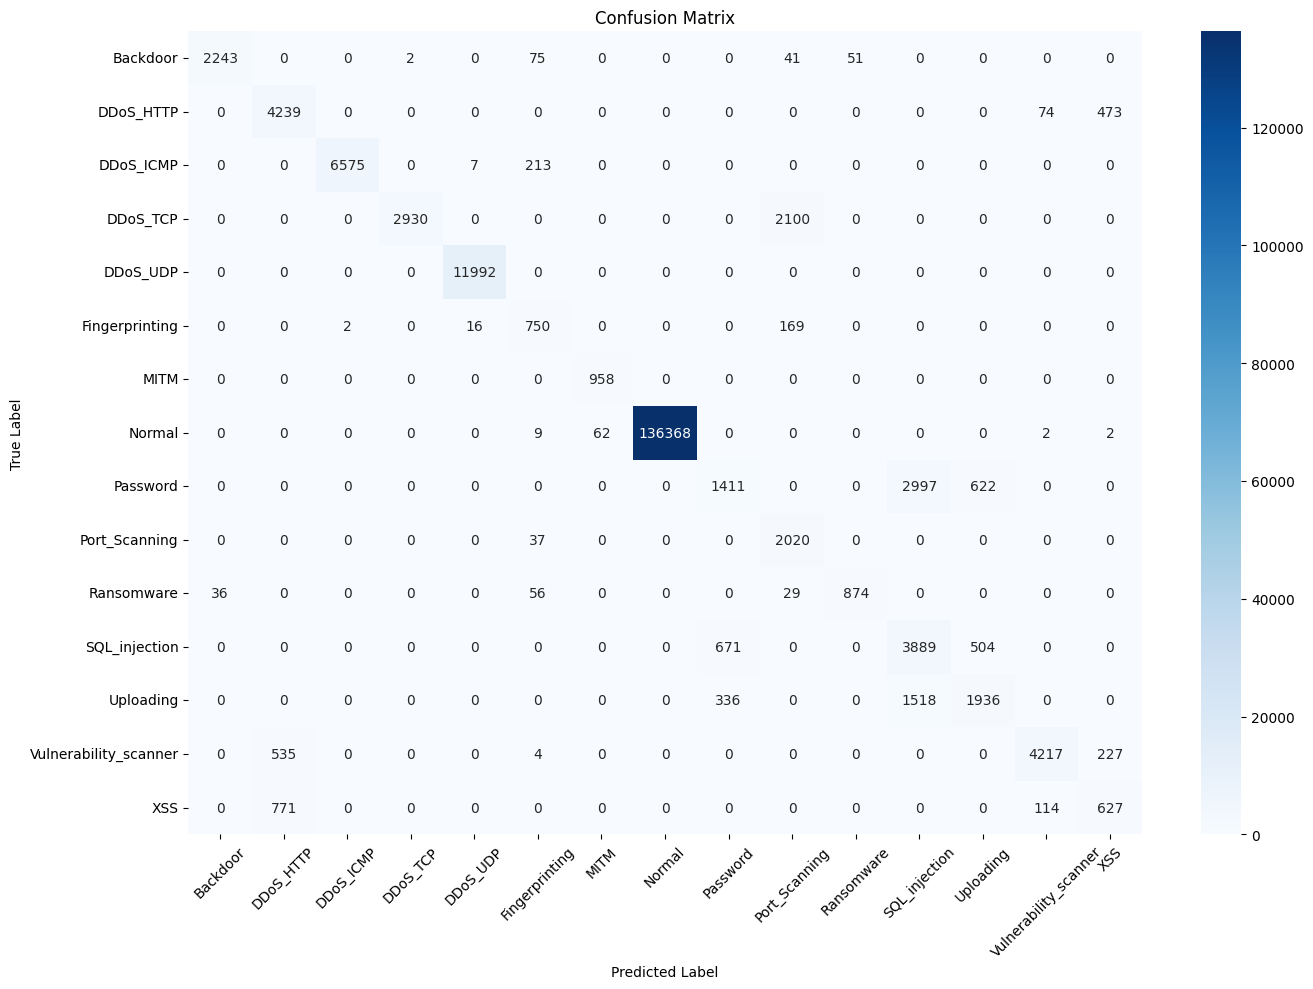

In [49]:
true_classes = y_test  # 如果是整数标签

# 3. 打印分类报告
all_labels = list(range(len(label_encoder.classes_)))  # 所有标签编号

print("\n📋 Classification Report for central model:")
print(classification_report(true_classes, predicted_classes,
                            labels=all_labels,
                            target_names=label_encoder.classes_, digits=4))

# 混淆矩阵
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# DNN

In [50]:
def create_dnn_model(input_dim, num_classes):
    model = Sequential()
    model.add(Dense(90, activation='relu', kernel_regularizer=l2(0.01), input_shape=(input_dim,)))
    model.add(Dense(90, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dense(num_classes, activation='softmax'))  # softmax 输出
    
    model.compile(optimizer=Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [51]:
DNN_MODEL_PATH = "central_model_DNN.h5"

In [52]:
# 先还原为二维
X_train_dnn = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_val_dnn = X_val.reshape(X_val.shape[0], X_val.shape[1])
X_test_dnn = X_test.reshape(X_test.shape[0], X_test.shape[1])

In [53]:
model = create_dnn_model(input_dim=X_train_dnn.shape[1], num_classes=num_classes)
checkpoint = ModelCheckpoint(filepath=DNN_MODEL_PATH, monitor="val_loss", verbose=1, save_best_only=True, mode="min", save_weights_only=True)
early_stopping = EarlyStopping(monitor="val_loss", mode="min", verbose=1, patience=10)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, mode="min", verbose=1, min_lr=0)

call_backs = [checkpoint, early_stopping, lr_reduce]

from tensorflow.keras import backend as K
import gc

history = model.fit(X_train, y_train, 
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, 
                    batch_size=BATCH_SIZE,
                    callbacks=call_backs,
                    class_weight=class_weights,
                    verbose=1)

Epoch 1/25
6021/6025 [============================>.] - ETA: 0s - loss: 0.8253 - accuracy: 0.9145
Epoch 1: val_loss improved from inf to 0.24970, saving model to central_model_DNN.h5
6025/6025 [==============================] - 30s 5ms/step - loss: 0.8253 - accuracy: 0.9145 - val_loss: 0.2497 - val_accuracy: 0.9139 - lr: 0.0010
Epoch 2/25
6019/6025 [============================>.] - ETA: 0s - loss: 0.6686 - accuracy: 0.9201
Epoch 2: val_loss improved from 0.24970 to 0.22165, saving model to central_model_DNN.h5
6025/6025 [==============================] - 31s 5ms/step - loss: 0.6686 - accuracy: 0.9200 - val_loss: 0.2216 - val_accuracy: 0.9205 - lr: 0.0010
Epoch 3/25
6017/6025 [============================>.] - ETA: 0s - loss: 0.6366 - accuracy: 0.9256
Epoch 3: val_loss did not improve from 0.22165
6025/6025 [==============================] - 36s 6ms/step - loss: 0.6366 - accuracy: 0.9256 - val_loss: 0.2234 - val_accuracy: 0.9290 - lr: 0.0010
Epoch 4/25
6020/6025 [======================

In [54]:
# 1. 加载客户端模型
model_path = "central_model_DNN.h5"
# 2. 加载权重
model.load_weights(model_path)

# 2. 使用模型进行预测
pred_probs = model.predict(X_test_dnn)
predicted_classes = np.argmax(pred_probs, axis=1)


6025/6025 [==============================] - 12s 2ms/step



📋 Classification Report for central model:
                       precision    recall  f1-score   support

             Backdoor     0.9764    0.8586    0.9137      2412
            DDoS_HTTP     0.9393    0.5921    0.7264      4786
            DDoS_ICMP     0.9983    0.9756    0.9868      6795
             DDoS_TCP     0.8922    0.7368    0.8071      5030
             DDoS_UDP     0.9986    0.9992    0.9989     11992
       Fingerprinting     0.7525    0.6489    0.6968       937
                 MITM     0.9979    1.0000    0.9990       958
               Normal     1.0000    1.0000    1.0000    136443
             Password     0.5251    0.4598    0.4903      5030
        Port_Scanning     0.5256    0.8031    0.6354      2057
           Ransomware     0.6667    0.9126    0.7705       995
        SQL_injection     0.4807    0.6254    0.5436      5064
            Uploading     0.6578    0.5016    0.5692      3790
Vulnerability_scanner     0.9473    0.8441    0.8927      4983
          

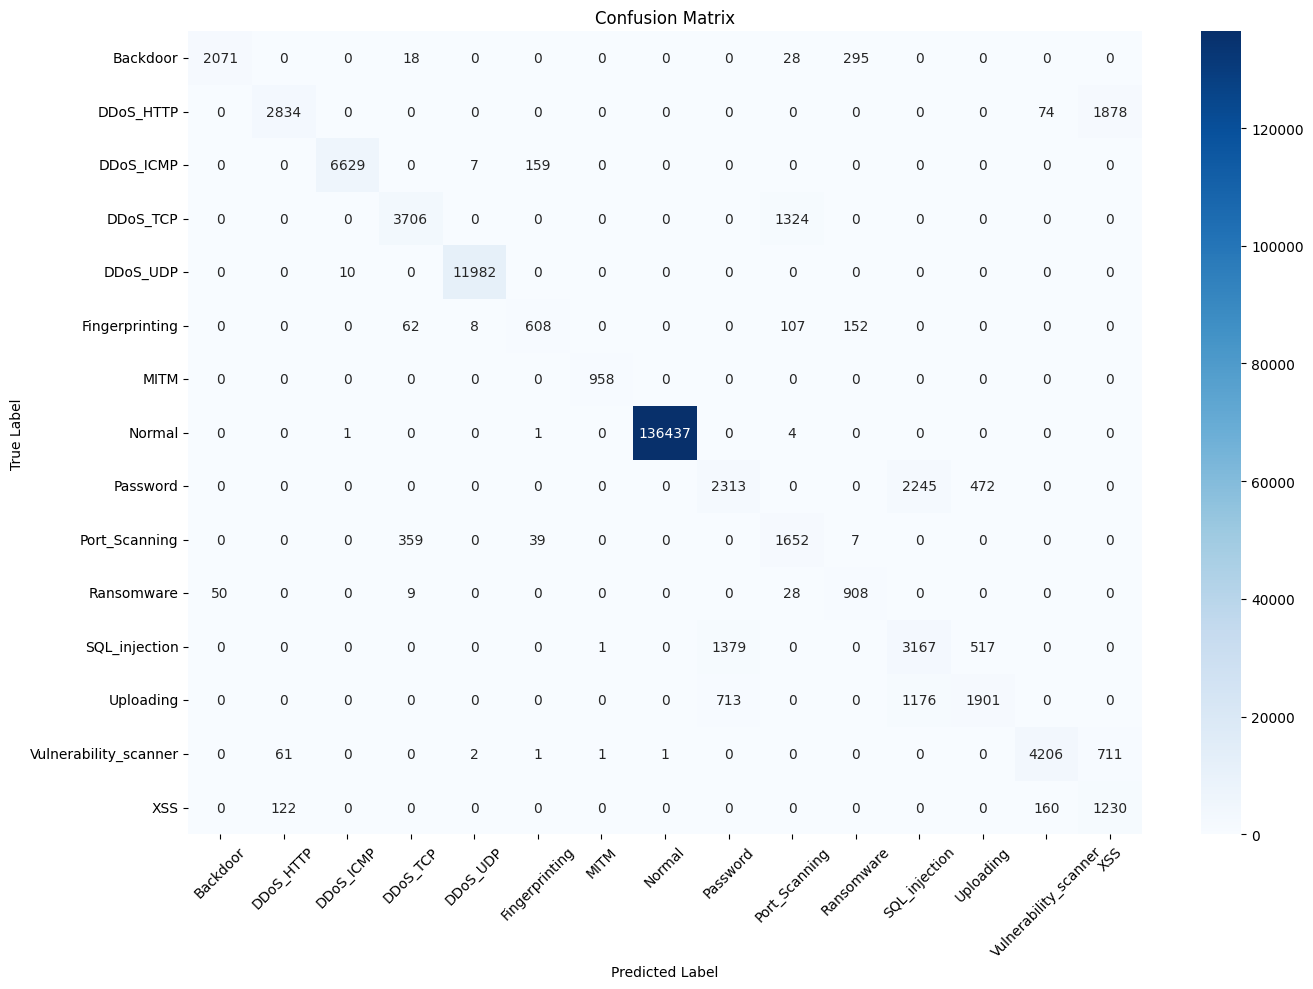

In [55]:
true_classes = y_test  # 如果是整数标签

# 3. 打印分类报告
all_labels = list(range(len(label_encoder.classes_)))  # 所有标签编号

print("\n📋 Classification Report for central model:")
print(classification_report(true_classes, predicted_classes,
                            labels=all_labels,
                            target_names=label_encoder.classes_, digits=4))

# 混淆矩阵
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# TabNet

In [56]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

clf = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_idxs=[], cat_dims=[], cat_emb_dim=1,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":50, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax'  # 'sparsemax' or 'entmax'
)


f:\Shiyun\Shiyun\.venv\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [57]:
clf.fit(
    X_train=X_train_dnn, y_train=y_train,
    eval_set=[(X_val_dnn, y_val)],
    eval_name=['val'],
    eval_metric=['accuracy'],
    max_epochs=200, patience=20,
    batch_size=1024, virtual_batch_size=128,
    num_workers=0, drop_last=False
)

epoch 0  | loss: 0.1614  | val_accuracy: 0.93538 |  0:04:56s
epoch 1  | loss: 0.12114 | val_accuracy: 0.9329  |  0:09:49s
epoch 2  | loss: 0.12029 | val_accuracy: 0.93962 |  0:14:47s
epoch 3  | loss: 0.11641 | val_accuracy: 0.93801 |  0:19:51s
epoch 4  | loss: 0.11517 | val_accuracy: 0.93565 |  0:25:02s
epoch 5  | loss: 0.11462 | val_accuracy: 0.93991 |  0:30:12s
epoch 6  | loss: 0.11568 | val_accuracy: 0.93662 |  0:35:13s
epoch 7  | loss: 0.11364 | val_accuracy: 0.93451 |  0:40:16s
epoch 8  | loss: 0.11557 | val_accuracy: 0.93819 |  0:45:17s
epoch 9  | loss: 0.11426 | val_accuracy: 0.94021 |  0:50:38s
epoch 10 | loss: 0.11307 | val_accuracy: 0.93767 |  0:57:35s
epoch 11 | loss: 0.11391 | val_accuracy: 0.93717 |  1:04:09s
epoch 12 | loss: 0.11406 | val_accuracy: 0.93739 |  1:10:56s
epoch 13 | loss: 0.11173 | val_accuracy: 0.93834 |  1:18:36s
epoch 14 | loss: 0.11066 | val_accuracy: 0.93342 |  1:24:26s
epoch 15 | loss: 0.11095 | val_accuracy: 0.93753 |  1:29:47s
epoch 16 | loss: 0.11064

f:\Shiyun\Shiyun\.venv\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [58]:
clf.save_model("tabnet_model")

Successfully saved model at tabnet_model.zip


'tabnet_model.zip'

In [59]:
preds = clf.predict(X_test_dnn)


📋 Classification Report for central model:
                       precision    recall  f1-score   support

             Backdoor     0.9960    0.9395    0.9669      2412
            DDoS_HTTP     0.6977    0.9847    0.8167      4786
            DDoS_ICMP     1.0000    0.9932    0.9966      6795
             DDoS_TCP     0.6608    1.0000    0.7958      5030
             DDoS_UDP     0.9996    1.0000    0.9998     11992
       Fingerprinting     0.9300    0.6521    0.7666       937
                 MITM     1.0000    1.0000    1.0000       958
               Normal     1.0000    1.0000    1.0000    136443
             Password     0.4428    0.8851    0.5903      5030
        Port_Scanning     0.0000    0.0000    0.0000      2057
           Ransomware     0.9699    0.9055    0.9366       995
        SQL_injection     1.0000    0.1619    0.2787      5064
            Uploading     0.6307    0.5016    0.5588      3790
Vulnerability_scanner     0.9575    0.8409    0.8954      4983
          

f:\Shiyun\Shiyun\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
f:\Shiyun\Shiyun\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
f:\Shiyun\Shiyun\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


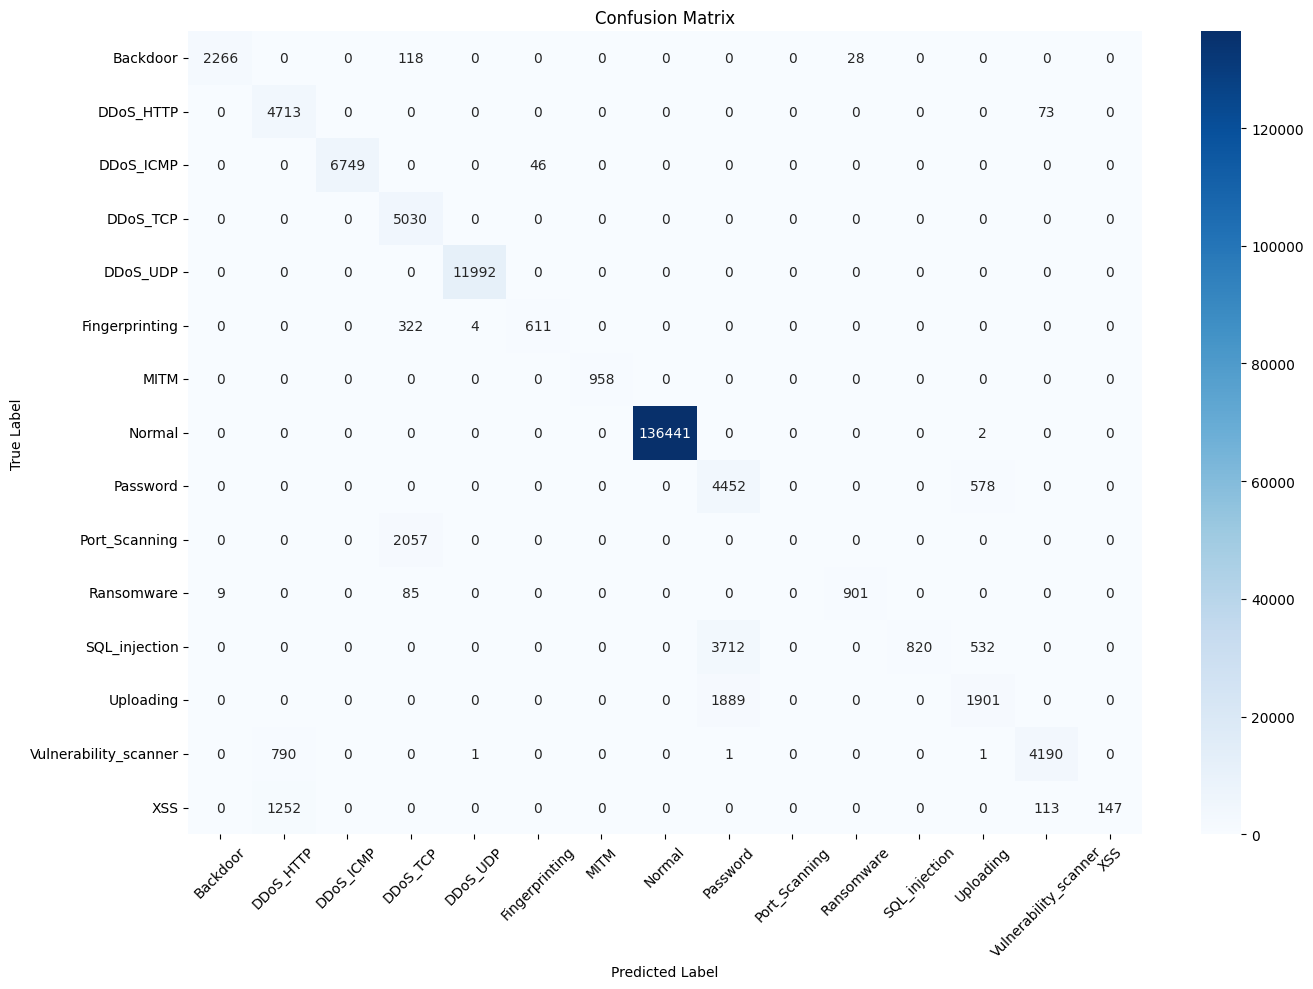

In [60]:
true_classes = y_test  # 如果是整数标签

# 3. 打印分类报告
all_labels = list(range(len(label_encoder.classes_)))  # 所有标签编号

print("\n📋 Classification Report for central model:")
print(classification_report(true_classes, preds,
                            labels=all_labels,
                            target_names=label_encoder.classes_, digits=4))

# 混淆矩阵
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Stacking

In [61]:
# 1. 加载模型
model_path_resnet = "central_model_ResNet50CNN.h5"
model_path_dnn = "central_model_DNN.h5"
# 2. 加载权重
model_resnet = create_model(input_shape=input_shape, n_classes=num_classes)
model_resnet.load_weights(model_path_resnet)

model_dnn = create_dnn_model(input_dim=X_train_dnn.shape[1], num_classes=num_classes)
model_dnn.load_weights(model_path_dnn)


In [62]:
# 模型输出：你可能用的是 softmax 输出，也可以是 argmax 的类别
# 这里假设是类别预测

val_pred_resnet = model_resnet.predict(X_val)       # shape: (N,)
val_pred_dnn = model_dnn.predict(X_val_dnn)          # shape: (N,)
val_pred_tabnet = clf.predict(X_val_dnn)    # shape: (N,)


6025/6025 [==============================] - 11s 2ms/step


In [63]:
val_pred_tabnet = clf.predict_proba(X_val_dnn)

In [64]:
val_pred_stack = np.hstack([
    val_pred_resnet,
    val_pred_dnn,
    val_pred_tabnet
])

In [65]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(val_pred_stack, y_val)

LogisticRegression(max_iter=1000)

6025/6025 [==============================] - 12s 2ms/step
Final Stacked Accuracy: 0.9473348410656486

📋 Classification Report for central model:
                       precision    recall  f1-score   support

             Backdoor     0.9904    0.9424    0.9658      2412
            DDoS_HTTP     0.7428    0.9352    0.8280      4786
            DDoS_ICMP     1.0000    0.9932    0.9966      6795
             DDoS_TCP     0.7971    1.0000    0.8871      5030
             DDoS_UDP     0.9996    1.0000    0.9998     11992
       Fingerprinting     0.7868    0.8154    0.8008       937
                 MITM     1.0000    1.0000    1.0000       958
               Normal     1.0000    1.0000    1.0000    136443
             Password     0.6965    0.2354    0.3519      5030
        Port_Scanning     1.0000    0.4803    0.6489      2057
           Ransomware     0.9769    0.8925    0.9328       995
        SQL_injection     0.4584    0.8584    0.5977      5064
            Uploading     0.6822   

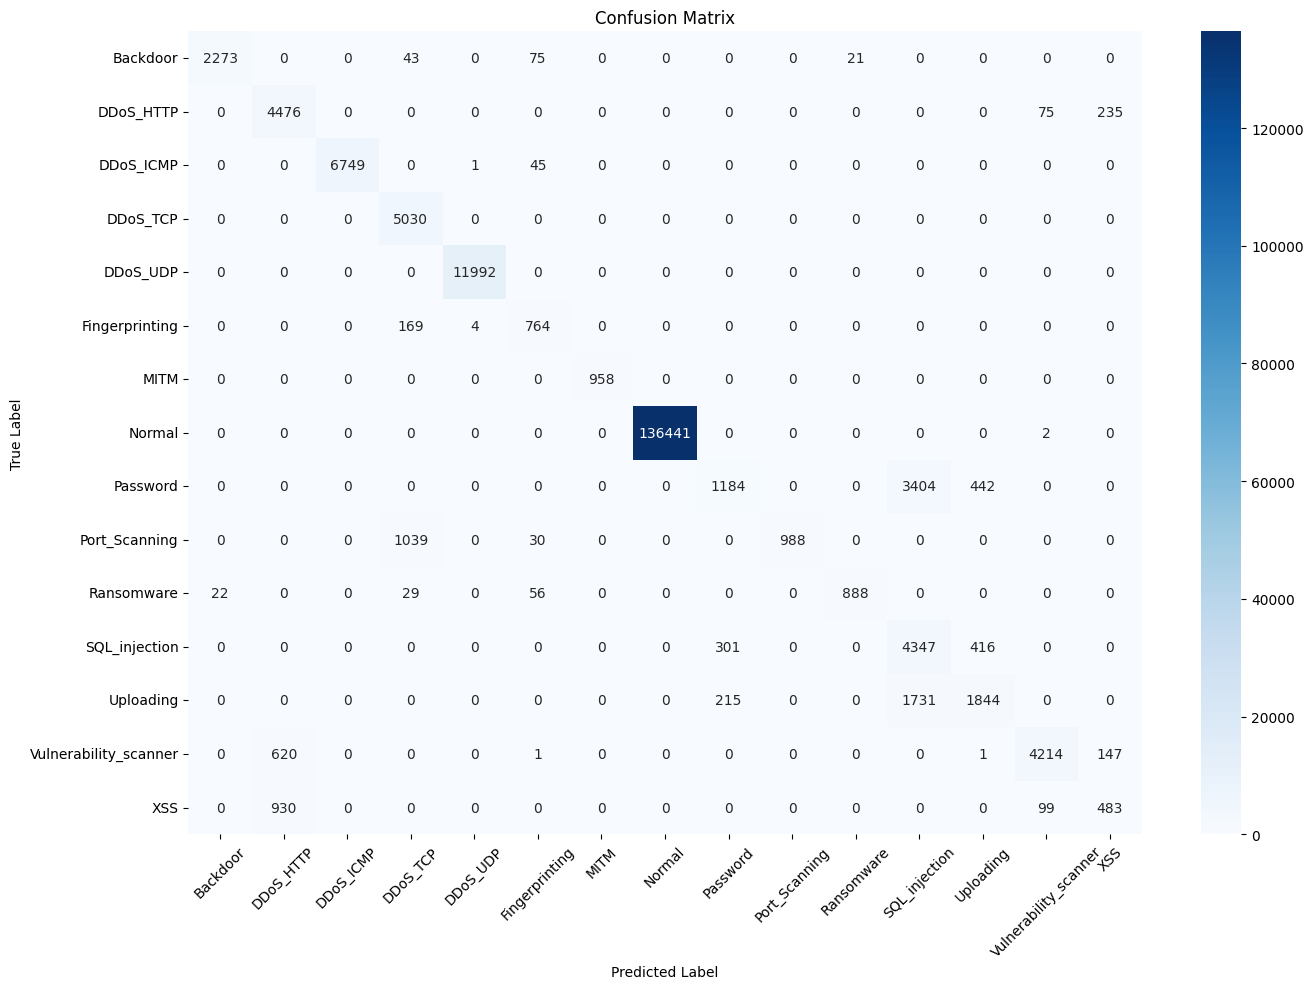

In [66]:
# 对 X_test 做预测
test_pred_stack = np.hstack([
    model_resnet.predict(X_test),
    model_dnn.predict(X_test_dnn),
    clf.predict_proba(X_test_dnn)
])

# 最终预测
final_preds = meta_model.predict(test_pred_stack)

from sklearn.metrics import accuracy_score
print("Final Stacked Accuracy:", accuracy_score(y_test, final_preds))

true_classes = y_test  # 如果是整数标签

# 3. 打印分类报告
all_labels = list(range(len(label_encoder.classes_)))  # 所有标签编号

print("\n📋 Classification Report for central model:")
print(classification_report(true_classes, final_preds,
                            labels=all_labels,
                            target_names=label_encoder.classes_, digits=4))

# 混淆矩阵
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [67]:
global_model = create_model(input_shape=input_shape, n_classes=num_classes)
# 1. 加载全局模型
model_path_global_model = "global_model_test3.h5"
# 2. 加载权重
global_model.load_weights(model_path_global_model)

# 2. 使用模型进行预测
pred_probs_global = global_model.predict(X_test_dnn)
predicted_classes_global = np.argmax(pred_probs_global, axis=1)


6025/6025 [==============================] - 177s 29ms/step



📋 Classification Report for global model:
                       precision    recall  f1-score   support

             Backdoor     0.9144    0.7488    0.8233      2412
            DDoS_HTTP     0.7095    0.9712    0.8200      4786
            DDoS_ICMP     1.0000    0.9941    0.9970      6795
             DDoS_TCP     0.7969    1.0000    0.8870      5030
             DDoS_UDP     1.0000    0.9949    0.9975     11992
       Fingerprinting     0.7604    0.8196    0.7889       937
                 MITM     1.0000    1.0000    1.0000       958
               Normal     1.0000    1.0000    1.0000    136443
             Password     0.4280    0.8839    0.5767      5030
        Port_Scanning     1.0000    0.4900    0.6577      2057
           Ransomware     0.6031    0.7437    0.6661       995
        SQL_injection     0.8545    0.1009    0.1805      5064
            Uploading     0.6320    0.4831    0.5476      3790
Vulnerability_scanner     0.9968    0.4417    0.6122      4983
           

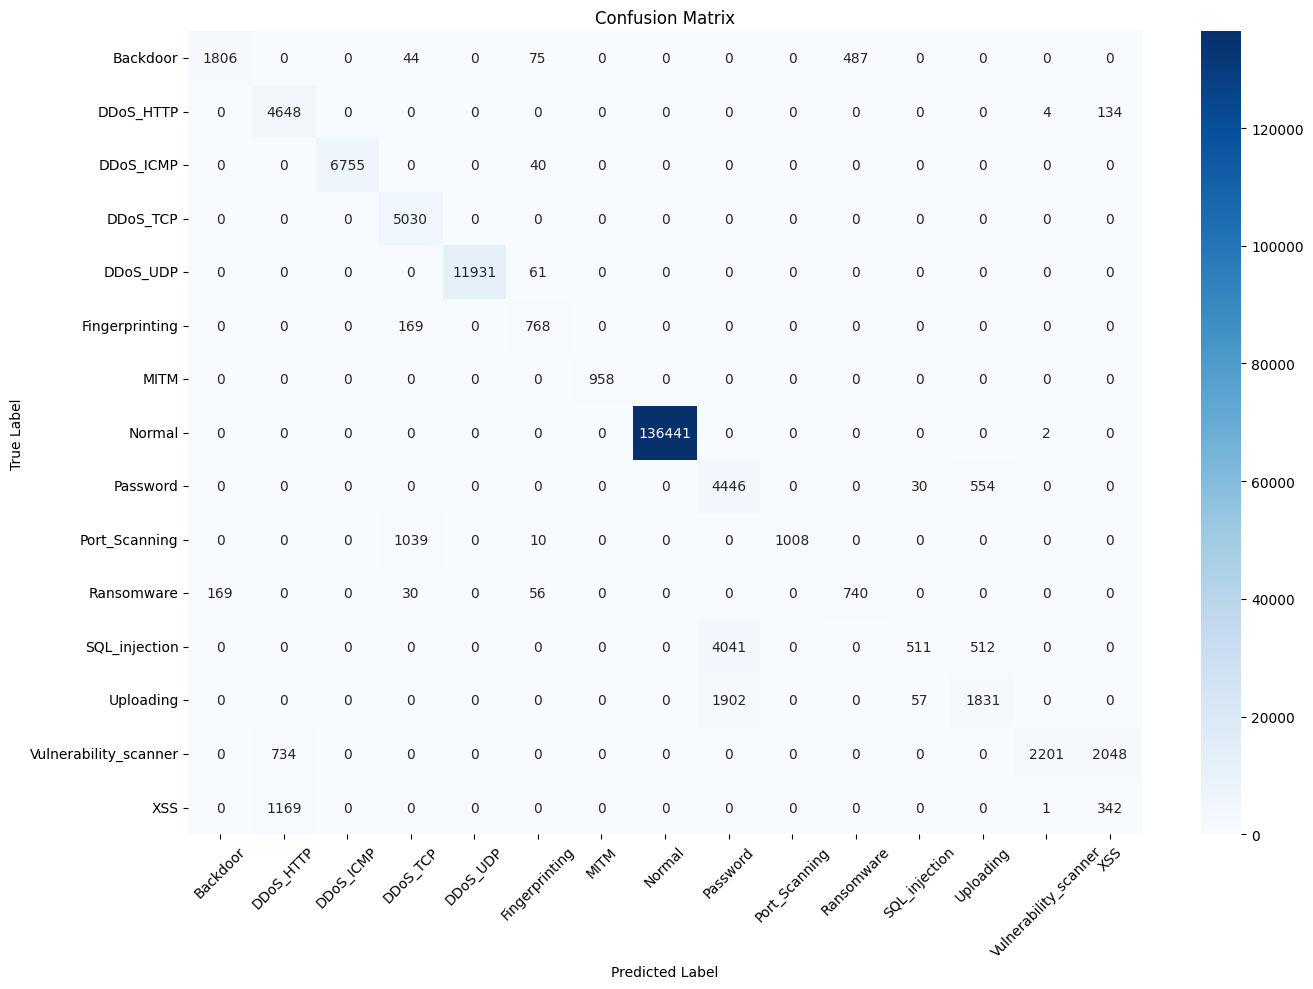

In [68]:
true_classes = y_test  # 如果是整数标签

# 3. 打印分类报告
all_labels = list(range(len(label_encoder.classes_)))  # 所有标签编号

print("\n📋 Classification Report for global model:")
print(classification_report(true_classes, predicted_classes_global,
                            labels=all_labels,
                            target_names=label_encoder.classes_, digits=4))

# 混淆矩阵
cm = confusion_matrix(y_test, predicted_classes_global)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()